In [68]:
import os
import pandas as pd
import numpy as np
import json
import shutil
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Import the data

Ultrasound Image

In [69]:
us_data = '/media/shadab/Others/Liver_Fibrosis_US_processed'

In [70]:
classes = os.listdir(us_data)
print(f'Classes: {classes}')

Classes: ['F1', 'F2', 'F3', 'F4']


In [71]:
# print the number of files in each class
for cls in classes:
    cls_path = os.path.join(us_data, cls)
    num_files = len(os.listdir(cls_path))
    print(f'Number of files in class {cls}: {num_files}')

Number of files in class F1: 861
Number of files in class F2: 793
Number of files in class F3: 857
Number of files in class F4: 1698


Clinical Data

In [72]:
clinical_data = pd.read_csv('/media/shadab/Others/cirrhosis+patient+survival+prediction+dataset-1/clinical_data_processed.csv')

In [73]:
clinical_data.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Ascites_missing,Hepatomegaly_missing,Spiders_missing
0,16.027556,3,1,124.941528,1,2,2,2,3,103.014440,...,52.794521,21.950609,52.539568,49.957522,51.842315,4.2,4.0,0,0,0
1,187.651451,1,1,116.094531,1,1,2,2,1,6.747292,...,18.037671,105.178334,41.257206,20.371681,64.155689,2.6,3.0,0,0,0
2,41.645562,3,1,168.079782,2,1,1,1,2,8.902527,...,71.195205,4.328053,33.212230,8.748673,36.351297,4.0,4.0,0,0,0
3,79.863273,3,1,109.587235,1,1,2,2,2,11.776173,...,21.445205,86.514845,16.831330,21.780531,49.061876,2.3,4.0,0,0,0
4,62.240429,2,3,46.122822,1,1,2,2,1,23.270758,...,48.364726,6.600513,41.086331,14.736283,30.393214,2.9,3.0,0,0,0


In [74]:
print(f"\nClass distribution:\n{clinical_data['Stage'].value_counts().sort_index()}")


Class distribution:
Stage
1.0     21
2.0     92
3.0    155
4.0    144
Name: count, dtype: int64


## Create Test Data

In [75]:
print("\n" + "="*80)
print("ANALYZING US IMAGE AVAILABILITY")
print("="*80)

# Count available US images per folder
us_counts = {}
for folder in ['F1', 'F2', 'F3', 'F4']:
    folder_path = os.path.join(us_data, folder)
    if os.path.exists(folder_path):
        num_files = len(os.listdir(folder_path))
        us_counts[folder] = num_files
        print(f"US images available in {folder}: {num_files}")
    else:
        us_counts[folder] = 0
        print(f"⚠️  {folder} not found")


ANALYZING US IMAGE AVAILABILITY
US images available in F1: 861
US images available in F2: 793
US images available in F3: 857
US images available in F4: 1698


In [76]:
print("\n" + "="*80)
print("CREATING HYBRID DATASET")
print("="*80)

# Create mapping from Stage values to folder names
stage_to_folder = {1.0: 'F1', 2.0: 'F2', 3.0: 'F3', 4.0: 'F4'}

# Build hybrid dataset by pairing clinical data with US images
hybrid_data = []
for idx, clinical_row in clinical_data.iterrows():
    stage = clinical_row['Stage']
    folder = stage_to_folder[stage]
    folder_path = os.path.join(us_data, folder)
    
    if os.path.exists(folder_path):
        us_images = os.listdir(folder_path)
        for us_image in us_images:
            us_image_path = os.path.join(folder_path, us_image)
            hybrid_data.append({
                'patient_idx': idx,
                'stage': stage,
                'folder': folder,
                'us_image': us_image,
                'us_image_path': us_image_path,
                'clinical_data': clinical_row
            })

hybrid_df = pd.DataFrame(hybrid_data)
print(f"Total paired samples created: {len(hybrid_df)}")
print(f"\nDistribution by stage:")
print(hybrid_df['folder'].value_counts().sort_index())


CREATING HYBRID DATASET
Total paired samples created: 468384

Distribution by stage:
folder
F1     18081
F2     72956
F3    132835
F4    244512
Name: count, dtype: int64
Total paired samples created: 468384

Distribution by stage:
folder
F1     18081
F2     72956
F3    132835
F4    244512
Name: count, dtype: int64


In [77]:
# Pick test cases - total ~50 cases based on availability
print("\n" + "="*80)
print("SELECTING TEST CASES (~50 total)")
print("="*80)

target_total = 50
stage_distribution = hybrid_df['stage'].value_counts().sort_index()

print(f"\nAvailable samples per stage:")
for stage, count in stage_distribution.items():
    print(f"  Stage {stage}: {count} samples")

# Calculate how many samples to pick from each stage
# Allocate proportionally based on availability
test_cases = []
total_selected = 0

for stage in sorted(hybrid_df['stage'].unique()):
    stage_data = hybrid_df[hybrid_df['stage'] == stage]
    available = len(stage_data)
    
    # Calculate proportional share of target_total
    proportion = available / len(hybrid_df)
    samples_for_stage = max(1, int(proportion * target_total))
    
    # Don't select more than available
    samples_for_stage = min(samples_for_stage, available)
    
    if samples_for_stage > 0:
        selected = stage_data.sample(n=samples_for_stage, random_state=42)
        test_cases.append(selected)
        total_selected += samples_for_stage
        print(f"  Stage {stage}: Selected {samples_for_stage} test cases (available: {available})")

test_hybrid = pd.concat(test_cases, ignore_index=True)

print(f"\n✅ Total test cases selected: {len(test_hybrid)}")
print("\nTest set class distribution:")
print(test_hybrid['folder'].value_counts().sort_index())


SELECTING TEST CASES (~50 total)

Available samples per stage:
  Stage 1.0: 18081 samples
  Stage 2.0: 72956 samples
  Stage 3.0: 132835 samples
  Stage 4.0: 244512 samples
  Stage 1.0: Selected 1 test cases (available: 18081)
  Stage 2.0: Selected 7 test cases (available: 72956)
  Stage 3.0: Selected 14 test cases (available: 132835)
  Stage 4.0: Selected 26 test cases (available: 244512)

✅ Total test cases selected: 48

Test set class distribution:
folder
F1     1
F2     7
F3    14
F4    26
Name: count, dtype: int64


In [78]:
# Create organized test dataset directory structure
print("\n" + "="*80)
print("ORGANIZING TEST SET")
print("="*80)

test_dataset_path = './Hybrid_Test_Dataset'
os.makedirs(test_dataset_path, exist_ok=True)

# Create subdirectories for each stage
for stage in range(1, 5):
    stage_dir = os.path.join(test_dataset_path, f'Stage_{stage}')
    os.makedirs(stage_dir, exist_ok=True)
    os.makedirs(os.path.join(stage_dir, 'US_Images'), exist_ok=True)

print(f"Test dataset directory created at: {test_dataset_path}")

# Copy test set US images
print("\nCopying test set US images...")
copy_count = 0
for idx, row in test_hybrid.iterrows():
    stage_num = int(row['stage'])
    stage_dir = os.path.join(test_dataset_path, f'Stage_{stage_num}')
    us_dest = os.path.join(stage_dir, 'US_Images', row['us_image'])
    
    # Copy image if not already copied
    if not os.path.exists(us_dest):
        try:
            shutil.copy(row['us_image_path'], us_dest)
            copy_count += 1
        except Exception as e:
            print(f"  ❌ Error copying {row['us_image']}: {e}")

print(f"\n✅ {copy_count} US images organized successfully!")


ORGANIZING TEST SET
Test dataset directory created at: ./Hybrid_Test_Dataset

Copying test set US images...

✅ 48 US images organized successfully!


In [79]:
# Save clinical data for test set
print("\n" + "="*80)
print("SAVING TEST SET CLINICAL DATA")
print("="*80)

# Extract clinical data for test set
test_clinical_data = []
for idx, row in test_hybrid.iterrows():
    clinical_row = row['clinical_data'].to_dict()
    clinical_row['us_image'] = row['us_image']
    clinical_row['Stage'] = row['stage']
    clinical_row['folder'] = row['folder']
    test_clinical_data.append(clinical_row)

test_clinical_df = pd.DataFrame(test_clinical_data)

# Save as CSV
test_dataset_path = './Hybrid_Test_Dataset'
os.makedirs(test_dataset_path, exist_ok=True)

test_clinical_path = os.path.join(test_dataset_path, 'test_clinical_data.csv')
test_clinical_df.to_csv(test_clinical_path, index=False)
print(f"✅ Clinical data saved to: {test_clinical_path}")

# Save as JSON with stage information
test_metadata = {
    'total_samples': len(test_hybrid),
    'stage_distribution': test_hybrid['folder'].value_counts().to_dict(),
    'samples': []
}

for idx, row in test_hybrid.iterrows():
    test_metadata['samples'].append({
        'patient_idx': int(row['patient_idx']),
        'Stage': float(row['stage']),
        'folder': row['folder'],
        'us_image': row['us_image'],
    })

metadata_path = os.path.join(test_dataset_path, 'test_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(test_metadata, f, indent=4)
print(f"✅ Metadata saved to: {metadata_path}")

print("\n" + "="*80)
print("TEST SET SUMMARY")
print("="*80)
print(f"Total test samples: {len(test_hybrid)}")
print("\nStage distribution:")
for stage in sorted(test_hybrid['stage'].unique()):
    count = len(test_hybrid[test_hybrid['stage'] == stage])
    folder = stage_to_folder[stage]
    print(f"  Stage {stage} ({folder}): {count} samples")


SAVING TEST SET CLINICAL DATA
✅ Clinical data saved to: ./Hybrid_Test_Dataset/test_clinical_data.csv
✅ Metadata saved to: ./Hybrid_Test_Dataset/test_metadata.json

TEST SET SUMMARY
Total test samples: 48

Stage distribution:
  Stage 1.0 (F1): 1 samples
  Stage 2.0 (F2): 7 samples
  Stage 3.0 (F3): 14 samples
  Stage 4.0 (F4): 26 samples


## Hybrid Model Testing

Testing the hybrid model using soft voting classifier combining DenseNet201 (US images) and XGBoost (clinical data)

In [80]:
print("\n" + "="*80)
print("LOADING TRAINED MODELS")
print("="*80)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load DenseNet201 model for US images
densenet_model_path = './Models/Ultrasound/Densenet201/densenet201_full_model.pt'
print(f"\nLoading DenseNet201 from: {densenet_model_path}")
densenet_model = torch.load(densenet_model_path, map_location=device, weights_only=False)
densenet_model.eval()
print("✅ DenseNet201 loaded successfully")

# Load XGBoost model for clinical data
xgboost_model_path = './Models/Clinical_Data/XGBoost/xgboost_clinical_model.json'
print(f"\nLoading XGBoost from: {xgboost_model_path}")
xgboost_model = xgb.Booster()
xgboost_model.load_model(xgboost_model_path)
print("✅ XGBoost loaded successfully")


LOADING TRAINED MODELS
Using device: cpu

Loading DenseNet201 from: ./Models/Ultrasound/Densenet201/densenet201_full_model.pt
✅ DenseNet201 loaded successfully

Loading XGBoost from: ./Models/Clinical_Data/XGBoost/xgboost_clinical_model.json
✅ XGBoost loaded successfully
✅ DenseNet201 loaded successfully

Loading XGBoost from: ./Models/Clinical_Data/XGBoost/xgboost_clinical_model.json
✅ XGBoost loaded successfully


In [81]:
# Load model accuracies for weighting
print("\n" + "="*80)
print("LOADING MODEL ACCURACIES")
print("="*80)

# Load XGBoost metrics
with open('./Models/Clinical_Data/XGBoost/model_metrics.json', 'r') as f:
    xgboost_metrics = json.load(f)
    
# DenseNet201 achieved 97% validation accuracy during training
xgboost_accuracy = xgboost_metrics.get('test_accuracy', 0.45)
densenet_accuracy = 0.97  # From DenseNet201 training results

print(f"XGBoost (Clinical) Accuracy: {xgboost_accuracy:.4f}")
print(f"DenseNet201 (US Image) Accuracy: {densenet_accuracy:.4f}")

# Calculate weights based on accuracies
A_b = xgboost_accuracy  # Blood test (clinical) accuracy
A_i = densenet_accuracy  # Image accuracy

w_b = A_b / (A_b + A_i)  # Weight for blood test model
w_i = A_i / (A_b + A_i)  # Weight for image model

print(f"\nCalculated Weights:")
print(f"  Clinical (XGBoost) weight: {w_b:.4f}")
print(f"  Image (DenseNet) weight: {w_i:.4f}")


LOADING MODEL ACCURACIES
XGBoost (Clinical) Accuracy: 0.4458
DenseNet201 (US Image) Accuracy: 0.9700

Calculated Weights:
  Clinical (XGBoost) weight: 0.3149
  Image (DenseNet) weight: 0.6851


In [82]:
# Define image preprocessing transforms (matching training)
print("\n" + "="*80)
print("SETTING UP IMAGE PREPROCESSING")
print("="*80)

# Images are already preprocessed, just need to convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

print("✅ Image preprocessing pipeline configured (images already preprocessed)")


SETTING UP IMAGE PREPROCESSING
✅ Image preprocessing pipeline configured (images already preprocessed)


In [83]:
def predict_hybrid(us_image_path, clinical_features, densenet_model, xgboost_model, transform, device, w_b, w_i):
    """
    Perform hybrid prediction using soft voting classifier
    
    Parameters:
    - us_image_path: Path to ultrasound image
    - clinical_features: Clinical data features (pandas Series or dict)
    - densenet_model: Trained DenseNet model
    - xgboost_model: Trained XGBoost model
    - transform: Image preprocessing transform
    - device: torch device
    - w_b: Weight for blood test (clinical) model
    - w_i: Weight for image model
    
    Returns:
    - final_prediction: Predicted class
    - P_hybrid: Final hybrid probabilities for all classes
    - P_b: Clinical model probabilities
    - P_i: Image model probabilities
    """
    
    # 1. Get DenseNet (image) prediction probabilities
    image = Image.open(us_image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_output = densenet_model(image_tensor)
        P_i = torch.softmax(image_output, dim=1).cpu().numpy()[0]  # Probabilities for each class
    
    # 2. Get XGBoost (clinical) prediction probabilities
    # Prepare clinical features as DMatrix
    clinical_features_df = pd.DataFrame([clinical_features])
    # Remove non-feature columns if present
    feature_columns = [col for col in clinical_features_df.columns 
                      if col not in ['Stage', 'us_image', 'folder']]
    clinical_features_clean = clinical_features_df[feature_columns]
    
    dmatrix = xgb.DMatrix(clinical_features_clean)
    P_b = xgboost_model.predict(dmatrix)[0]  # Probabilities for each class
    
    # 3. Calculate weighted hybrid probabilities using soft voting
    # P_hybrid,c = (w_b * P_b,c) + (w_i * P_i,c) for each class c
    P_hybrid = (w_b * P_b) + (w_i * P_i)
    
    # 4. Final prediction is the class with highest hybrid probability
    final_prediction = np.argmax(P_hybrid)
    
    return final_prediction, P_hybrid, P_b, P_i

print("✅ Hybrid prediction function defined")

✅ Hybrid prediction function defined


In [84]:
# Run predictions on test set
print("\n" + "="*80)
print("RUNNING HYBRID MODEL PREDICTIONS ON TEST SET")
print("="*80)

# Load test clinical data
test_clinical_path = './Hybrid_Test_Dataset/test_clinical_data.csv'
test_clinical_df = pd.read_csv(test_clinical_path)

print(f"Loaded {len(test_clinical_df)} test samples")

# Store predictions
predictions = []
true_labels = []
all_hybrid_probs = []
all_clinical_probs = []
all_image_probs = []

print("\nProcessing test samples...")
for idx, row in test_clinical_df.iterrows():
    # Get image path
    stage_num = int(row['Stage'])
    us_image_name = row['us_image']
    us_image_path = os.path.join('./Hybrid_Test_Dataset', f'Stage_{stage_num}', 'US_Images', us_image_name)
    
    # Get clinical features
    clinical_features = row.drop(['us_image', 'folder'])
    
    # Get true label (0-indexed)
    true_label = int(row['Stage']) - 1
    
    # Make prediction
    pred, P_hybrid, P_b, P_i = predict_hybrid(
        us_image_path, clinical_features, 
        densenet_model, xgboost_model, 
        transform, device, w_b, w_i
    )
    
    predictions.append(pred)
    true_labels.append(true_label)
    all_hybrid_probs.append(P_hybrid)
    all_clinical_probs.append(P_b)
    all_image_probs.append(P_i)
    
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/{len(test_clinical_df)} samples")

print(f"\n✅ Completed predictions for all {len(test_clinical_df)} test samples")


RUNNING HYBRID MODEL PREDICTIONS ON TEST SET
Loaded 48 test samples

Processing test samples...
  Processed 10/48 samples
  Processed 10/48 samples
  Processed 20/48 samples
  Processed 20/48 samples
  Processed 30/48 samples
  Processed 30/48 samples
  Processed 40/48 samples
  Processed 40/48 samples

✅ Completed predictions for all 48 test samples

✅ Completed predictions for all 48 test samples


In [85]:
# Calculate and display results
print("\n" + "="*80)
print("HYBRID MODEL EVALUATION RESULTS")
print("="*80)

# Calculate accuracy
hybrid_accuracy = accuracy_score(true_labels, predictions)
print(f"\nHybrid Model Accuracy: {hybrid_accuracy:.4f} ({hybrid_accuracy*100:.2f}%)")

# Compare with individual model accuracies
print(f"\nModel Comparison:")
print(f"  XGBoost (Clinical) Accuracy: {xgboost_accuracy:.4f} ({xgboost_accuracy*100:.2f}%)")
print(f"  DenseNet201 (Image) Accuracy: {densenet_accuracy:.4f} ({densenet_accuracy*100:.2f}%)")
print(f"  Hybrid Model Accuracy: {hybrid_accuracy:.4f} ({hybrid_accuracy*100:.2f}%)")
print(f"\n  Improvement over Clinical-only: {(hybrid_accuracy - xgboost_accuracy)*100:.2f}%")
print(f"  Improvement over Image-only: {(hybrid_accuracy - densenet_accuracy)*100:.2f}%")

# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
class_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
print("\n" + classification_report(true_labels, predictions, target_names=class_names, digits=4))


HYBRID MODEL EVALUATION RESULTS

Hybrid Model Accuracy: 1.0000 (100.00%)

Model Comparison:
  XGBoost (Clinical) Accuracy: 0.4458 (44.58%)
  DenseNet201 (Image) Accuracy: 0.9700 (97.00%)
  Hybrid Model Accuracy: 1.0000 (100.00%)

  Improvement over Clinical-only: 55.42%
  Improvement over Image-only: 3.00%

DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

     Stage 1     1.0000    1.0000    1.0000         1
     Stage 2     1.0000    1.0000    1.0000         7
     Stage 3     1.0000    1.0000    1.0000        14
     Stage 4     1.0000    1.0000    1.0000        26

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48




CONFUSION MATRIX


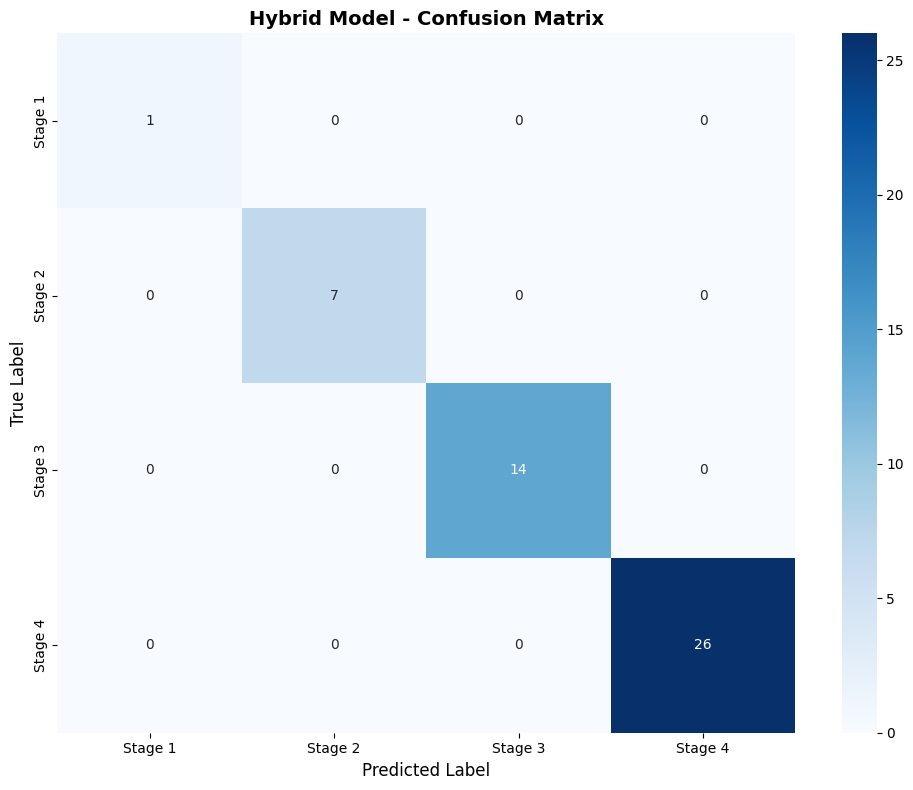


Confusion Matrix:
[[ 1  0  0  0]
 [ 0  7  0  0]
 [ 0  0 14  0]
 [ 0  0  0 26]]


In [86]:
# Visualize confusion matrix
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)


EXAMPLE PREDICTIONS WITH PROBABILITY DISTRIBUTIONS


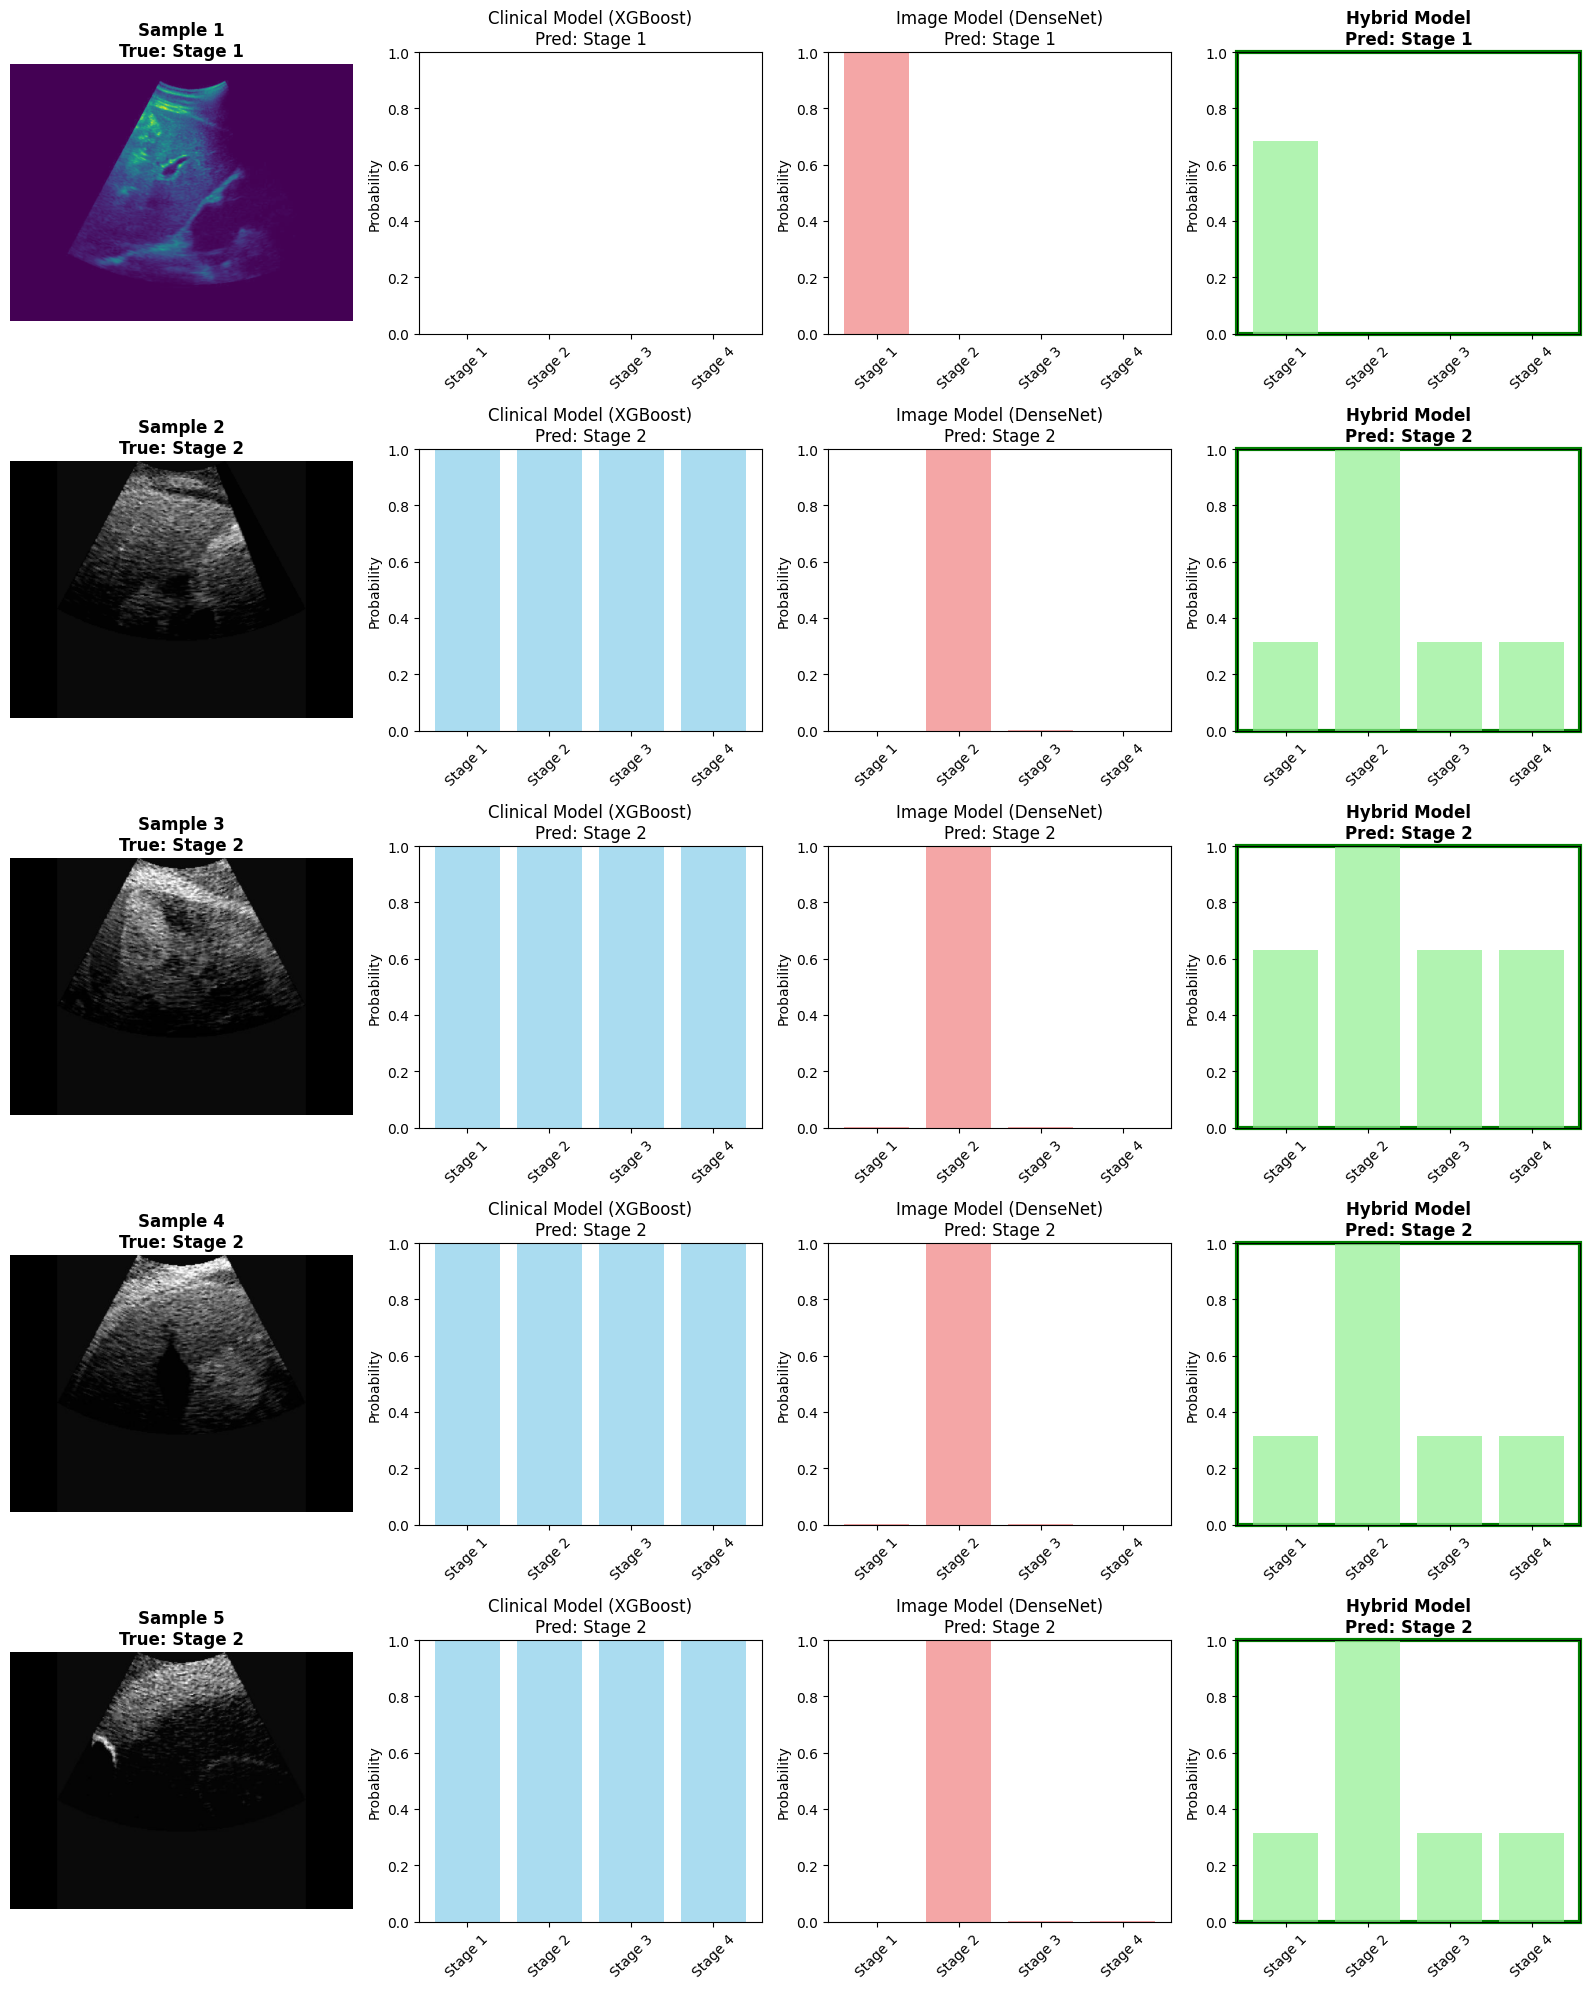

In [87]:
# Visualize example predictions with probability distributions
print("\n" + "="*80)
print("EXAMPLE PREDICTIONS WITH PROBABILITY DISTRIBUTIONS")
print("="*80)

# Show first 5 test samples
num_examples = min(5, len(test_clinical_df))
fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4*num_examples))

if num_examples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_examples):
    row = test_clinical_df.iloc[i]
    stage_num = int(row['Stage'])
    us_image_name = row['us_image']
    us_image_path = os.path.join('./Hybrid_Test_Dataset', f'Stage_{stage_num}', 'US_Images', us_image_name)
    
    # Load and display image
    img = Image.open(us_image_path)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Sample {i+1}\nTrue: Stage {stage_num}', fontweight='bold')
    axes[i, 0].axis('off')
    
    # Plot clinical model probabilities
    axes[i, 1].bar(class_names, all_clinical_probs[i], color='skyblue', alpha=0.7)
    axes[i, 1].set_title(f'Clinical Model (XGBoost)\nPred: Stage {predictions[i]+1}')
    axes[i, 1].set_ylabel('Probability')
    axes[i, 1].set_ylim([0, 1])
    axes[i, 1].tick_params(axis='x', rotation=45)
    
    # Plot image model probabilities
    axes[i, 2].bar(class_names, all_image_probs[i], color='lightcoral', alpha=0.7)
    axes[i, 2].set_title(f'Image Model (DenseNet)\nPred: Stage {np.argmax(all_image_probs[i])+1}')
    axes[i, 2].set_ylabel('Probability')
    axes[i, 2].set_ylim([0, 1])
    axes[i, 2].tick_params(axis='x', rotation=45)
    
    # Plot hybrid model probabilities
    axes[i, 3].bar(class_names, all_hybrid_probs[i], color='lightgreen', alpha=0.7)
    axes[i, 3].set_title(f'Hybrid Model\nPred: Stage {predictions[i]+1}', fontweight='bold')
    axes[i, 3].set_ylabel('Probability')
    axes[i, 3].set_ylim([0, 1])
    axes[i, 3].tick_params(axis='x', rotation=45)
    
    # Highlight correct/incorrect prediction
    if predictions[i] == (stage_num - 1):
        axes[i, 3].patch.set_edgecolor('green')
        axes[i, 3].patch.set_linewidth(3)
    else:
        axes[i, 3].patch.set_edgecolor('red')
        axes[i, 3].patch.set_linewidth(3)

plt.tight_layout()
plt.show()

In [88]:
# # Save hybrid model results
# print("\n" + "="*80)
# print("SAVING HYBRID MODEL RESULTS")
# print("="*80)

# # Create results directory
# results_dir = './Models/Hybrid'
# os.makedirs(results_dir, exist_ok=True)

# # Save detailed results
# results = {
#     'model_type': 'Soft Voting Classifier (DenseNet201 + XGBoost)',
#     'test_accuracy': float(hybrid_accuracy),
#     'xgboost_accuracy': float(xgboost_accuracy),
#     'densenet_accuracy': float(densenet_accuracy),
#     'weights': {
#         'clinical_weight': float(w_b),
#         'image_weight': float(w_i)
#     },
#     'improvement': {
#         'over_clinical': float(hybrid_accuracy - xgboost_accuracy),
#         'over_image': float(hybrid_accuracy - densenet_accuracy)
#     },
#     'confusion_matrix': cm.tolist(),
#     'predictions': [int(p) for p in predictions],
#     'true_labels': [int(t) for t in true_labels]
# }

# results_path = os.path.join(results_dir, 'hybrid_model_results.json')
# with open(results_path, 'w') as f:
#     json.dump(results, f, indent=4)

# print(f"✅ Results saved to: {results_path}")

# # Save predictions CSV
# predictions_df = test_clinical_df.copy()
# predictions_df['true_label'] = [t + 1 for t in true_labels]
# predictions_df['predicted_label'] = [p + 1 for p in predictions]
# predictions_df['correct'] = predictions_df['true_label'] == predictions_df['predicted_label']

# # Add probability columns
# for i, class_name in enumerate(class_names):
#     predictions_df[f'hybrid_prob_{class_name}'] = [probs[i] for probs in all_hybrid_probs]
#     predictions_df[f'clinical_prob_{class_name}'] = [probs[i] for probs in all_clinical_probs]
#     predictions_df[f'image_prob_{class_name}'] = [probs[i] for probs in all_image_probs]

# predictions_csv = os.path.join(results_dir, 'hybrid_predictions.csv')
# predictions_df.to_csv(predictions_csv, index=False)
# print(f"✅ Predictions saved to: {predictions_csv}")

# print("\n" + "="*80)
# print("HYBRID MODEL TESTING COMPLETE")
# print("="*80)